# SewerTris Sibling Types

This notebook describes the main types of SewerTris project siblings that can be created from a completed base project. The examples use the completed Stillwater project from `example_02_Stillwater_sewertris_project.ipynb` as the parent model.

The key idea is that `clone_sibling(...)` records the intended changes and copies only the parent artifacts that are still reusable. Then `rerun_from_parent_parameters(...)` reads those changes and reruns the dependent workflow from the earliest affected step.

## Setup

Load the local refactored SewerTris package and the completed Stillwater base project.

In [1]:
from pathlib import Path
import importlib
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris

for _module_name in [
    "sewertris._deps",
    "sewertris.domain",
    "sewertris.layout",
    "sewertris.roads",
    "sewertris.topography",
    "sewertris.sewer_network",
    "sewertris.hydrology",
    "sewertris.design",
    "sewertris.swmm",
    "sewertris.plots",
    "sewertris.project",
    "sewertris",
]:
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

import sewertris as sp

base_project_path = EXAMPLES_DIR / "output_example_2_project"

base_project = sp.SewerTrisProject.load(base_project_path)
print("Base project:", base_project.project_file)
print("Vector format:", base_project.geometry_format)


Base project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json
Vector format: gpkg


## Sibling Families

A sibling can modify one step or several steps at once. If multiple changes are provided, SewerTris restarts from the earliest affected step and reruns everything downstream.

In [2]:
sibling_catalog = [
    {
        "family": "Domain sibling",
        "change_keys": "domain, shapefile_path, domain_mask, cell_size_m",
        "rerun_from": "Step 1 - Urban Domain Definition",
        "purpose": "Test a different city boundary, raster mask, grid size, or outlet/domain setup.",
    },
    {
        "family": "Tetris block sibling",
        "change_keys": "tetromino_set, tetrominoes, tetromino_colors",
        "rerun_from": "Step 2 - Tetris Block Definition",
        "purpose": "Compare urban morphology generated by different block libraries.",
    },
    {
        "family": "Layout sibling",
        "change_keys": "layout, georeferenced",
        "rerun_from": "Step 3 - Stochastic Tetris Completion",
        "purpose": "Regenerate the stochastic filled board while keeping domain and block definitions.",
    },
    {
        "family": "Road sibling",
        "change_keys": "road_width, roads, simplify_tol, keep_holes",
        "rerun_from": "Step 4 - Road Network Extraction",
        "purpose": "Test wider/narrower roads or different boundary extraction settings.",
    },
    {
        "family": "Land-use sibling",
        "change_keys": "land_use_distribution, land_use, seed",
        "rerun_from": "Step 5 - Land-Use Assignment",
        "purpose": "Compare residential/commercial/industrial allocation strategies.",
    },
    {
        "family": "Topography sibling",
        "change_keys": "topography_config, config, dem",
        "rerun_from": "Step 6 - Synthetic DEM Generation",
        "purpose": "Test different slope, roughness, terrain, or drainage assumptions.",
    },
    {
        "family": "Sewer network sibling",
        "change_keys": "network, sewer_network, block_size, prefer_slope, max_search_depth",
        "rerun_from": "Step 7 - Sewer Network Generation",
        "purpose": "Compare main/secondary/tertiary network search and routing settings.",
    },
    {
        "family": "Flow predesign sibling",
        "change_keys": "land_use_info, gwi_factor_ls_per_m, rdii_factor_ls_per_m2",
        "rerun_from": "Step 8 - Sewer Flow Predesign",
        "purpose": "Test population demand, GWI scaling, and RDII area scaling assumptions.",
    },
    {
        "family": "Pipe design sibling",
        "change_keys": "diameters, standard_diameters_mm, materials, material_fractions",
        "rerun_from": "Step 9 - Pipe Sizing and Hydraulic Properties",
        "purpose": "Compare design standards, material mixes, roughness, cover, and slope criteria.",
    },
    {
        "family": "Dynamic input / SWMM sibling",
        "change_keys": "swmm_options, options_dict, bwf, dwf, gwi_coefficient, rdii, rainfall",
        "rerun_from": "Step 10 - Dynamic Flow Input Definition",
        "purpose": "Test temporal BWF/DWF patterns, GWI inflow, rainfall, RDII, and SWMM options.",
    },
]

pd.DataFrame(sibling_catalog)


,family,change_keys,rerun_from,purpose
0,Domain sibling,"domain, shapefile_path, domain_mask, cell_size_m",Step 1 - Urban Domain Definition,"Test a different city boundary, raster mask, g..."
1,Tetris block sibling,"tetromino_set, tetrominoes, tetromino_colors",Step 2 - Tetris Block Definition,Compare urban morphology generated by differen...
2,Layout sibling,"layout, georeferenced",Step 3 - Stochastic Tetris Completion,Regenerate the stochastic filled board while k...
3,Road sibling,"road_width, roads, simplify_tol, keep_holes",Step 4 - Road Network Extraction,Test wider/narrower roads or different boundar...
4,Land-use sibling,"land_use_distribution, land_use, seed",Step 5 - Land-Use Assignment,Compare residential/commercial/industrial allo...
5,Topography sibling,"topography_config, config, dem",Step 6 - Synthetic DEM Generation,"Test different slope, roughness, terrain, or d..."
6,Sewer network sibling,"network, sewer_network, block_size, prefer_slo...",Step 7 - Sewer Network Generation,Compare main/secondary/tertiary network search...
7,Flow predesign sibling,"land_use_info, gwi_factor_ls_per_m, rdii_facto...",Step 8 - Sewer Flow Predesign,"Test population demand, GWI scaling, and RDII ..."
8,Pipe design sibling,"diameters, standard_diameters_mm, materials, m...",Step 9 - Pipe Sizing and Hydraulic Properties,"Compare design standards, material mixes, roug..."
9,Dynamic input / SWMM sibling,"swmm_options, options_dict, bwf, dwf, gwi_coef...",Step 10 - Dynamic Flow Input Definition,"Test temporal BWF/DWF patterns, GWI inflow, ra..."


## Sibling Recipes

The recipes below are examples of `changes={...}` dictionaries. They do not run the model by themselves. Use them as templates for creating a new sibling project.

In [3]:
sibling_recipes = {
    "tetris_4_blocks": {
        "tetromino_set": "I_O_T_S_only",
    },
    "road_width_20m": {
        "road_width": 20,
    },
    "commercial_core": {
        "land_use_distribution": {
            "RESIDENTIAL": 0.45,
            "COMMERCIAL": 0.25,
            "INDUSTRIAL": 0.10,
            "PUBLIC": 0.10,
            "RECREATIONAL": 0.10,
        },
        "seed": 7,
    },
    "higher_gwi_rdii_predesign": {
        "gwi_factor_ls_per_m": 0.0005,
        "rdii_factor_ls_per_m2": 0.00005,
    },
    "restricted_pipe_catalog": {
        "diameters": [200, 300, 450, 600, 900, 1200],
        "materials": {"PVC": 0.8, "CONCRETE": 0.2},
    },
    "stronger_evening_bwf": {
        "bwf": {
            "hourly_id": "1",
            "hourly_values": [
                0.45, 0.35, 0.30, 0.30, 0.45, 0.85,
                1.20, 1.35, 1.25, 1.10, 1.00, 1.00,
                0.95, 0.95, 1.00, 1.10, 1.30, 1.55,
                1.65, 1.55, 1.35, 1.10, 0.80, 0.60,
            ],
        },
    },
    "higher_dynamic_infiltration": {
        "gwi_coefficient": 0.0003,
        "rdii": {
            "imperv_pct": 15,
            "width": 150,
            "slope": 0.01,
        },
    },
    "combined_layout_and_hydrology": {
        "tetromino_set": "I_O_T_S_only",
        "road_width": 20,
        "gwi_factor_ls_per_m": 0.0005,
        "diameters": [200, 300, 450, 600, 900, 1200],
    },
}

pd.DataFrame(
    [
        {"recipe": name, "changes": changes}
        for name, changes in sibling_recipes.items()
    ]
)


,recipe,changes
0,tetris_4_blocks,{'tetromino_set': 'I_O_T_S_only'}
1,road_width_20m,{'road_width': 20}
2,commercial_core,{'land_use_distribution': {'RESIDENTIAL': 0.45...
3,higher_gwi_rdii_predesign,"{'gwi_factor_ls_per_m': 0.0005, 'rdii_factor_l..."
4,restricted_pipe_catalog,"{'diameters': [200, 300, 450, 600, 900, 1200],..."
5,stronger_evening_bwf,"{'bwf': {'hourly_id': '1', 'hourly_values': [0..."
6,higher_dynamic_infiltration,"{'gwi_coefficient': 0.0003, 'rdii': {'imperv_p..."
7,combined_layout_and_hydrology,"{'tetromino_set': 'I_O_T_S_only', 'road_width'..."


## Create a Sibling

This cell creates a project sibling from one recipe. By default it only creates and records the sibling. Set `RUN_SELECTED_SIBLING = True` to rerun the dependent workflow.

Sibling project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_sibling_types/road_width_20m/sewertris_project.json
Changes: {'road_width': 20}
Rerun from: 04_road_network_extraction
Copied artifacts: ['domain_mask', 'grid_meta', 'layout_blocks', 'input_domain']
[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_sibling_types/road_width_20m/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_sibling_types/road_width_20m/road_outer_shell.gpkg
✅ Exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_sibling_types/road_width_20m/city_blocks.gpkg
Original boundary CRS: EPSG:32614
Original roads CRS: EPSG:32614

Boundary extent:
X range: 667161.00 to 678581.00
Y range: 3994824.67 to 4006644.67
Boundary CRS: EPSG:32614
Boundary bounds: [ 667160.9958307  3994824.67323194  678580.9958307  4006644.67323194]
Grid shape: (1203, 1163)
Grid exte

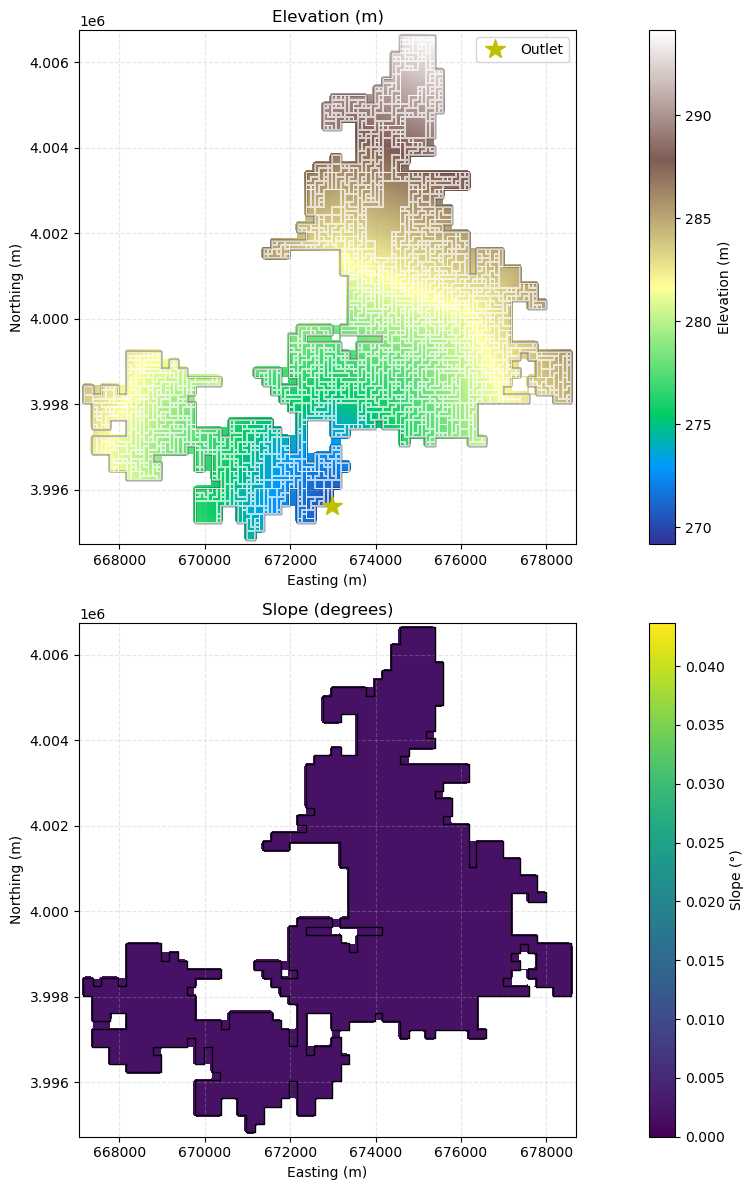


Terrain Statistics:
Elevation range: 269.17m - 294.11m
Mean elevation: 281.12m
Mean slope: 0.00°
Max slope: 0.04°

Drainage Statistics:
Points with proper drainage: 505116.0 out of 537894 (93.9%)
✅ Extracted 3473 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_sibling_types/road_width_20m/manholes.gpkg

Path Statistics:
Head: MH1914  →  Target: MH2191
Segments: 114
Total length: 15200.0 m
Total drop: 23.97 m
Avg slope: 0.150%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 1213 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
📊 V2 initial missing outlet pipes: 2145
V2 iteration 1: start=MH033, status=committed, chain_len=6, cost=953.14, remaining=2139
V2 iteration 2: start=MH039, status=committed, chain_len=7, cost=1132.88, remaining=2132
V2 iteration 3: start=MH045, status=committed, chain_len=28, cost=3422.61, remaining=2104
V2 iteration 4: start=MH057, status=committed, cha

In [4]:
SIBLING_OUTPUT_ROOT = EXAMPLES_DIR / "output_example_sibling_types"
SELECTED_SIBLING = "road_width_20m"
RUN_SELECTED_SIBLING = True

changes = sibling_recipes[SELECTED_SIBLING]
sibling = base_project.clone_sibling(
    SIBLING_OUTPUT_ROOT / SELECTED_SIBLING,
    name=f"Stillwater sibling: {SELECTED_SIBLING}",
    changes=changes,
)

print("Sibling project:", sibling.project_file)
print("Changes:", sibling.metadata["lineage"]["changes"])
print("Rerun from:", sibling.metadata["lineage"]["rerun_from"])
print("Copied artifacts:", list(sibling.metadata["lineage"]["copied_artifacts"]))

results = None
if RUN_SELECTED_SIBLING:
    results = sibling.rerun_from_parent_parameters(
        base_project,
        scenario_name="bwf_gwi_rdii",
        run_flow_components=True,
    )
    print("Completed sibling:", sibling.project_file)
else:
    print("Set RUN_SELECTED_SIBLING = True to execute this sibling.")


## Compare After Running

After a sibling has been executed, compare it against the Stillwater base project with `plot_two_models(...)`.

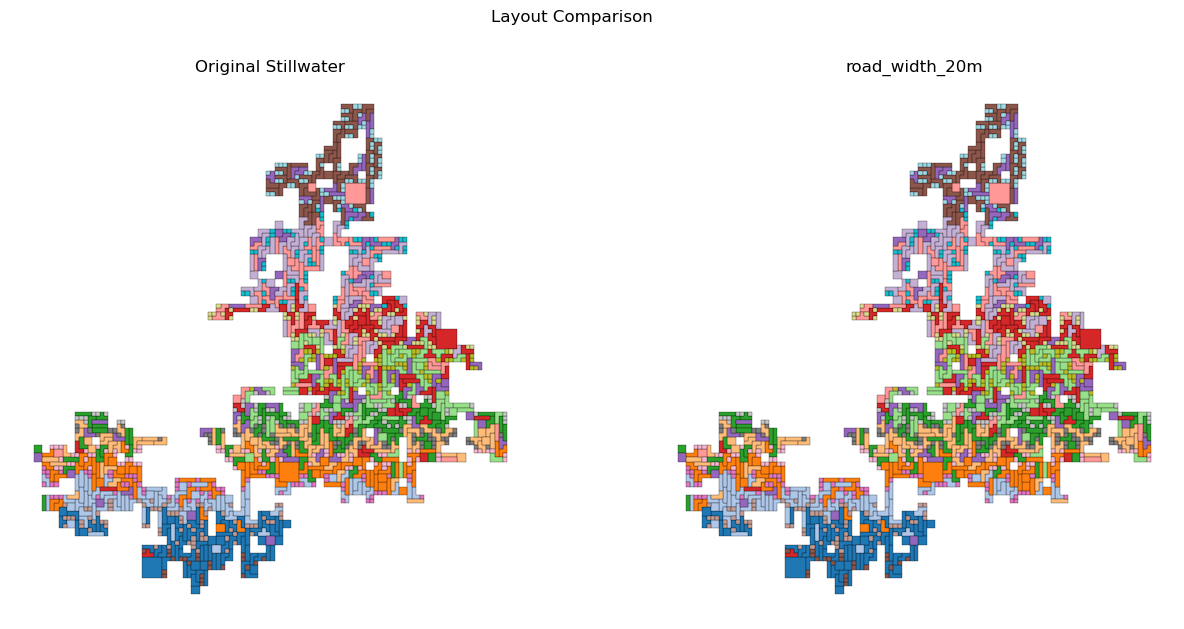

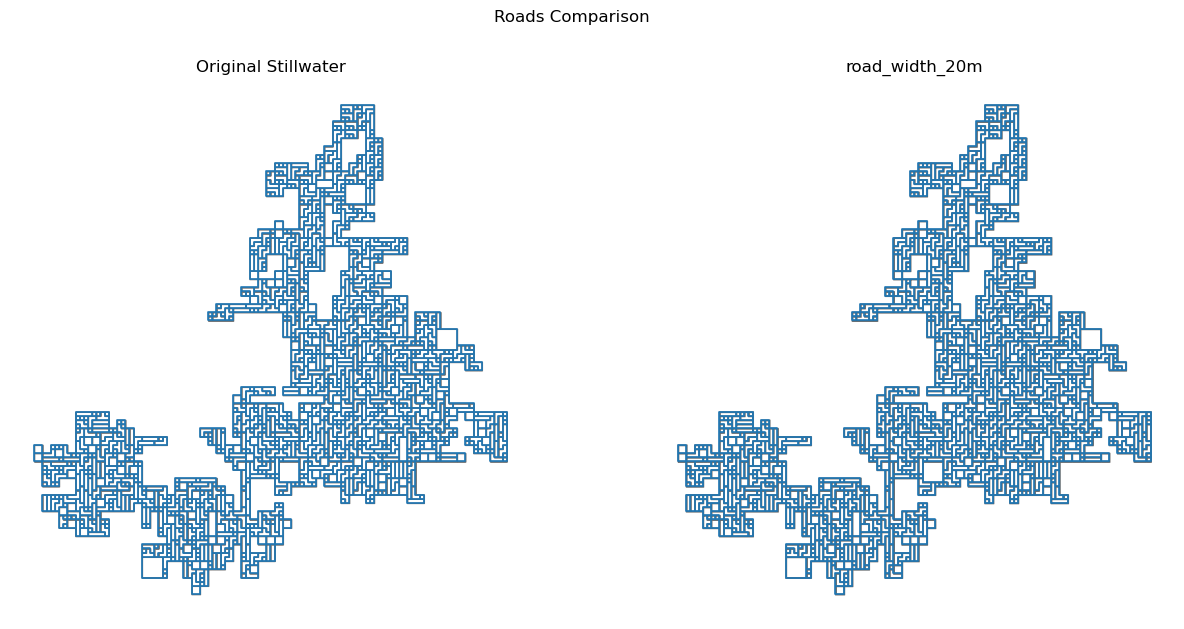

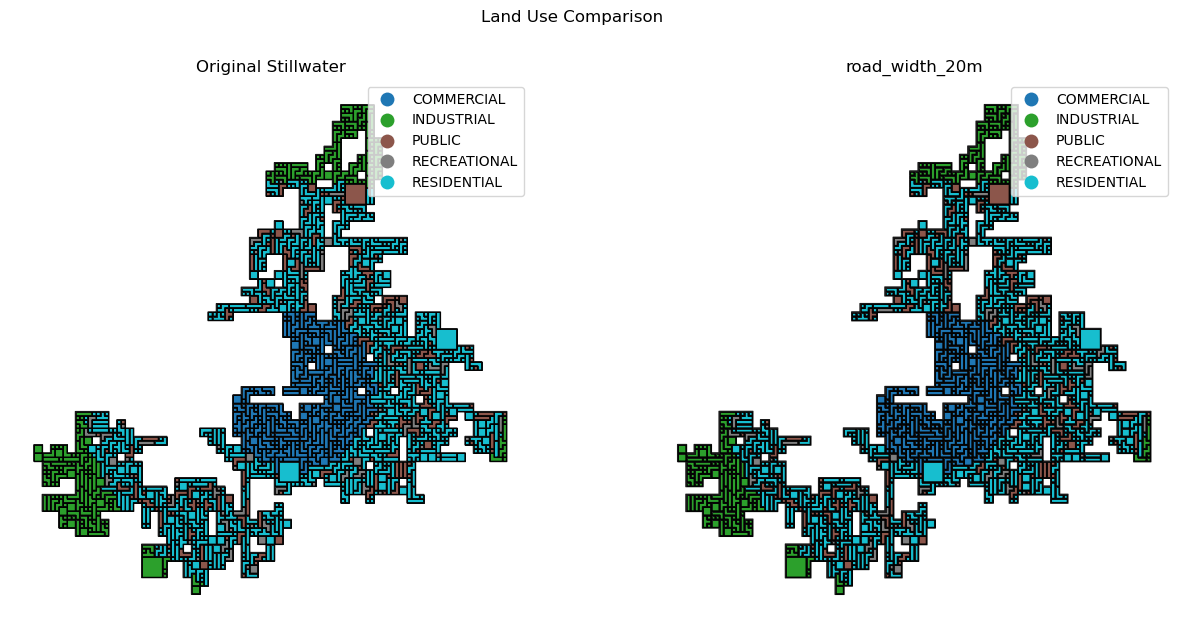

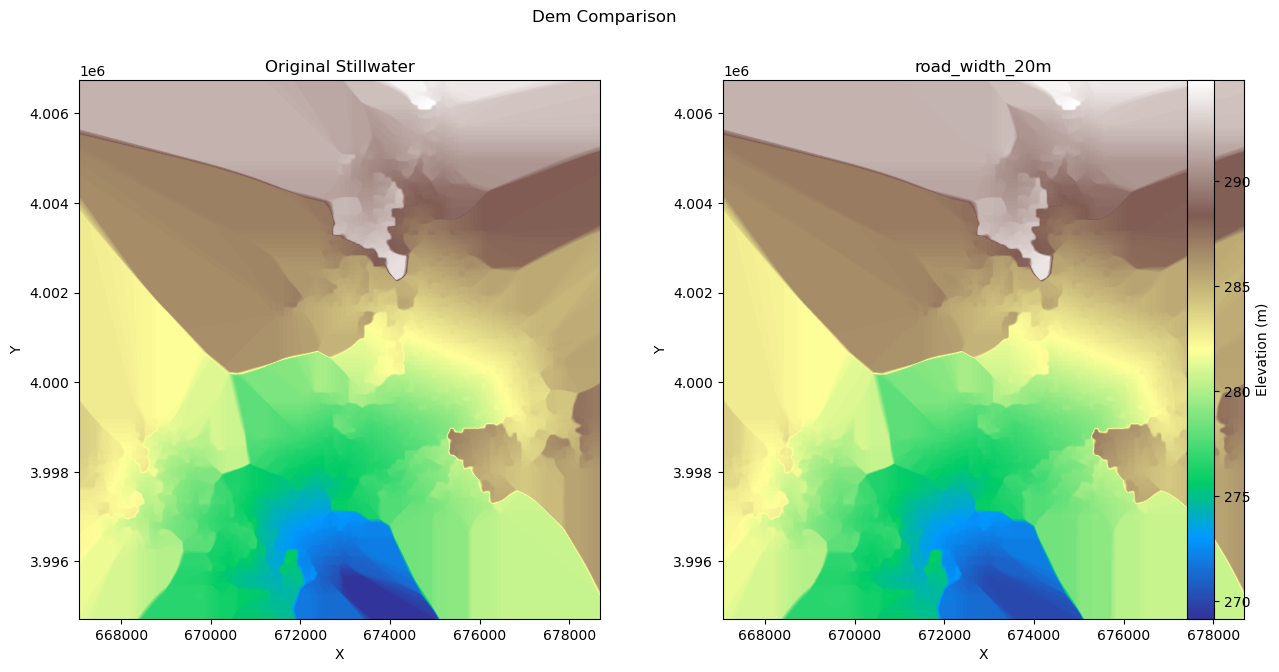

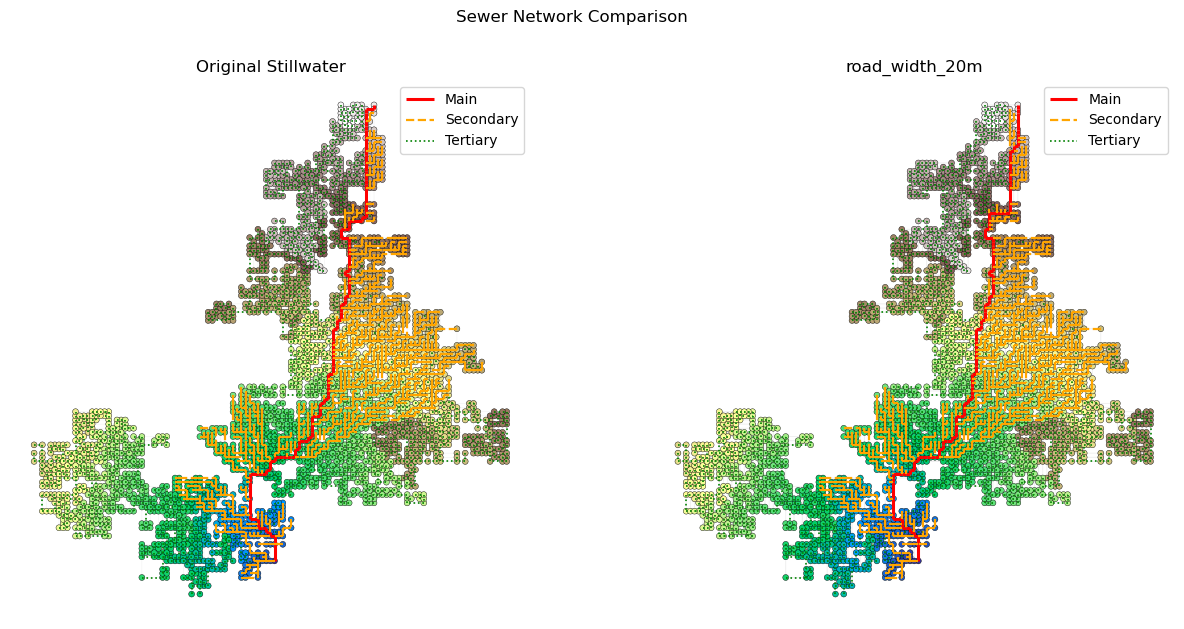

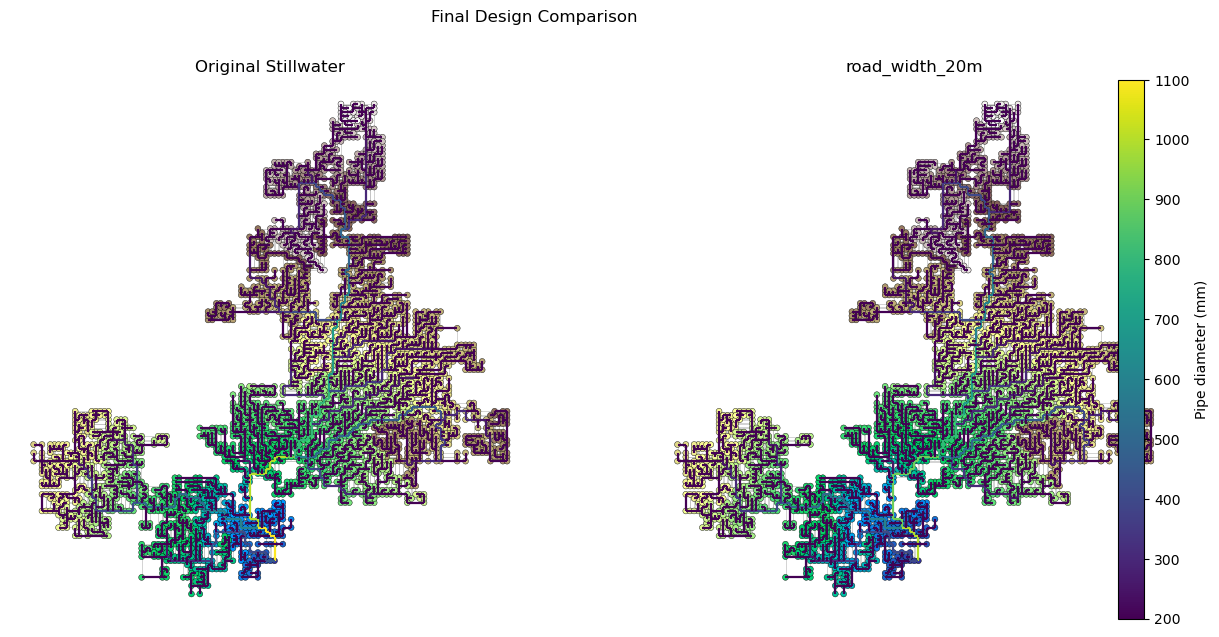

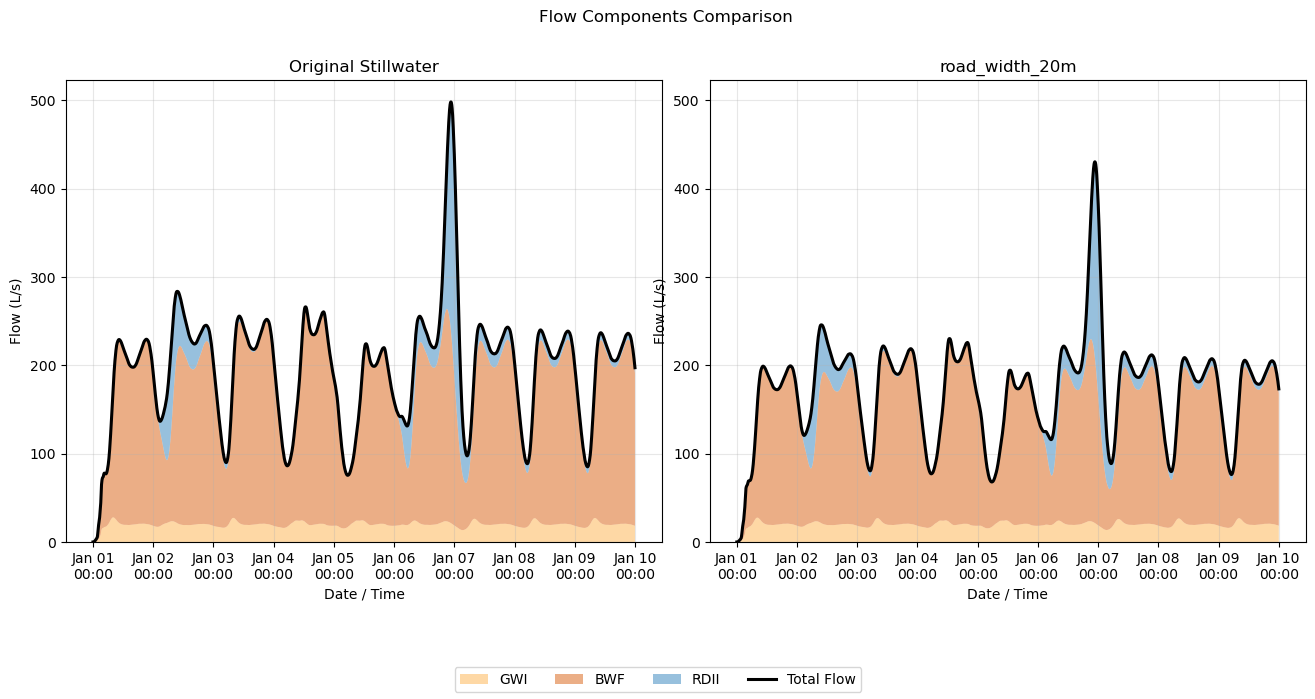

In [5]:
if RUN_SELECTED_SIBLING:
    options = base_project.step_parameters("10_dynamic_flow_input_definition_base_model").get("options_dict", {})
    start = f"{options.get('START_DATE', '01/01/1990')} {options.get('START_TIME', '00:00:00')}"
    end = f"{options.get('END_DATE', '01/10/1990')} {options.get('END_TIME', '00:00:00')}"

    comparison_figures = sp.plot_two_models(
        "all",
        base_project,
        sibling,
        labels=("Original Stillwater", SELECTED_SIBLING),
        scenario_name="bwf_gwi_rdii",
        start=start,
        end=end,
        diameter_field="diameter_mm",
        manhole_color_field="elevation",
    )
else:
    print("Run a selected sibling first to generate comparison plots.")


## Notes on Combined Siblings

Combined siblings are allowed. For example, if a sibling changes both `road_width` and `gwi_coefficient`, SewerTris restarts from Step 4 because road width changes the road geometry and everything downstream must be regenerated. The GWI coefficient is then applied later when the SWMM scenario is rebuilt.

This rule is conservative: the earliest affected step controls the rerun point.